# Basic Agent

## 1. Define Tools

In [2]:
# prebuilt-tool
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

/tmp/ipykernel_34840/2600722235.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [3]:
# custom defined tool
from langchain_core.tools import tool

@tool
def calculator(expression: str) -> str:
    """Compute the mathematical expression that can be translated by eval build-in function of python."""
    try:
        res = eval(expression)
        return f"the result of {expression} is {res}"
    except Exception as e:
        return f"{e}"

# 2. Concatenate Tools

In [4]:
tools = [calculator, search]

# 3. Declare LLM

In [5]:
from langchain_groq import ChatGroq
from decouple import Config, RepositoryEnv
env_config = Config(RepositoryEnv("./.env"))

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    # model="llama-3.1-8b-instant",
    temperature=1.0,
    max_retries=2,
    api_key=env_config("GROQ_API_KEY"),
)

# test llm
query = "Tell me what's LangGraph used for in just one sentence."
response = llm.invoke(query)
print(response)

/home/niuniu/Documents/tmp/test/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


content='LangGraph is an AI model developed by Meta, used for generating and processing human-like language, enabling a wide range of natural language processing applications such as text generation, language translation, and conversational interfaces.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 48, 'total_tokens': 90, 'completion_time': 0.179683994, 'completion_tokens_details': None, 'prompt_time': 0.006998632, 'prompt_tokens_details': None, 'queue_time': 0.037517856, 'total_time': 0.186682626}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e8a51-ae6b-7e01-b263-ac3ab3dde132-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 48, 'output_tokens': 42, 'total_tokens': 90}


# 4. Bind Tools to LLM

In [6]:
llm_tools = llm.bind_tools(tools)

# test bind llm
res = llm_tools.invoke("Solve 35-9+25.")
print(res)

content='' additional_kwargs={'tool_calls': [{'id': 't2786mfma', 'function': {'arguments': '{"expression":"35-9+25"}', 'name': 'calculator'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 342, 'total_tokens': 360, 'completion_time': 0.031062972, 'completion_tokens_details': None, 'prompt_time': 0.017289987, 'prompt_tokens_details': None, 'queue_time': 0.144699649, 'total_time': 0.048352959}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e8a51-b01f-73d2-9363-789ccfbe9588-0' tool_calls=[{'name': 'calculator', 'args': {'expression': '35-9+25'}, 'id': 't2786mfma', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 342, 'output_tokens': 18, 'total_tokens': 360}


# 5. Define State

In [7]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# 6. Define Nodes

In [8]:
# define chatbot node
from langchain_core.messages import HumanMessage

def chatbot_node(state: State) -> State:
    """Gatekeeper: answer directly or request a tool"""
    system_message = (
        "You are a helpful assistant.\n"
        "Use the 'web_search' tool for real-time inforamtion and 'calculator' for math related problems."
        "Otherwise answer directly."
    )

    messages = [
        {"role": "system", "content": system_message},
        *state["messages"],
    ]
    # print(f"DEBUG: {state["messages"]}\n")
    response = llm_tools.invoke(messages)
    return {"messages": [response]}

In [9]:
# define tool node
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools) 

# 7. Define Routing Logic

In [10]:
from typing import Literal

def should_continue(state: State) -> Literal["tools", "end"]:
    last = state["messages"][-1]
    print(f"DEBUG TOOLS: {last.tool_calls}\n\n")
    return "tools" if last.tool_calls else "end"

# 8. Construct Graph

In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

graph_tools = StateGraph(State)
graph_tools.add_node("chatbot", chatbot_node)
graph_tools.add_node("tools", tool_node)

graph_tools.add_edge(START, "chatbot")
graph_tools.add_conditional_edges("chatbot", should_continue, {"tools": "tools", "end": END})
graph_tools.add_edge("tools", "chatbot")

# 9. Compile Graph

In [12]:
agent = graph_tools.compile(checkpointer=MemorySaver())

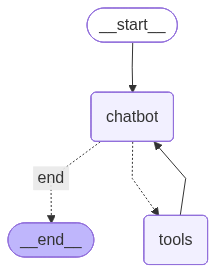

In [13]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

# Test the graph

In [14]:
def talk_to_agent(query: str, thread_id: str="test"):
    config = {"configurable": {"thread_id": thread_id}}
    res = agent.invoke({"messages": [HumanMessage(content=query)]}, config)
    print(f"👨: {query}\n🤖: {res["messages"][-1].content}")

talk_to_agent("Hello my name is John.")
talk_to_agent("Solve 35 % 9.")
talk_to_agent("Search latest news on Langgraph and synthetize in one sentence.")

DEBUG TOOLS: []


👨: Hello my name is John.
🤖: Hello John, it's nice to meet you. Is there something I can help you with or would you like to chat?
DEBUG TOOLS: [{'name': 'calculator', 'args': {'expression': '35 % 9'}, 'id': '2ecptdbtn', 'type': 'tool_call'}]


DEBUG TOOLS: []


👨: Solve 35 % 9.
🤖: The result of 35 % 9 is 8.
DEBUG TOOLS: [{'name': 'duckduckgo_search', 'args': {'query': 'latest news on Langgraph'}, 'id': 'jsa53xs7k', 'type': 'tool_call'}]


DEBUG TOOLS: []


👨: Search latest news on Langgraph and synthetize in one sentence.
🤖: LangGraph, a framework for stateful AI workflow orchestration, has reached significant milestones with the release of LangGraph 2.0 in February 2026 and has evolved into a production-ready platform powering mission-critical AI applications at several major companies.


We can see that for the greeting, no tools were called - so only direct answer was given. And for "35%9" it called the calculator tool and for the search latest news request, duckduckgo_search tool was called.